# **1. Perkenalan Dataset**


**Sumber Dataset**: Kaggle — FIFA World Cup 2026 Player Performance oleh Rauffauzanrambe.

Dataset ini berisi statistik performa pemain selama Piala Dunia FIFA 2026, mencakup 54.600 baris data dengan 75 kolom yang meliputi informasi demografis pemain (usia, kebangsaan, posisi, klub), statistik pertandingan (menit bermain, gol, assist, operan, tembakan), dan metrik performa lanjutan (expected goals, rating pemain, kontribusi ofensif/defensif).

**Tujuan Proyek (Multi-Output):**
1. **Regresi** — Memprediksi jumlah gol (*goals*) yang akan dicetak pemain.
2. **Klasifikasi** — Mengklasifikasikan posisi pemain (*position*) ke dalam 4 kategori: Defender, Forward, Goalkeeper, Midfielder.

Pendekatan multi-output ini memungkinkan model untuk belajar representasi fitur yang menangkap kedua aspek performa secara simultan.

# **2. Import Library**

Pada tahap ini, dilakukan import pustaka Python yang dibutuhkan untuk analisis data, preprocessing, dan pembangunan model.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


# **3. Memuat Dataset**

Dataset dimuat dari file CSV menggunakan pandas. Dilakukan pengecekan awal untuk memahami struktur data.

In [9]:
DATA_PATH = '../fifa_world_cup_2026_player_performance.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Dataset shape: (54600, 75)
Number of rows: 54600
Number of columns: 75


In [10]:
df.head()

,player_id,player_name,age,nationality,team,jersey_number,position,height_cm,weight_kg,preferred_foot,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
0,P00055,Rodri Fati,26,Spanish,Spain,3,Goalkeeper,195,75,Left,...,1.1,44.2,55.9,42.0,51.8,0,0,242,0,5.8
1,P00070,Ansu Le Normand,19,Spanish,Spain,18,Midfielder,178,75,Right,...,3.5,38.2,43.7,31.1,52.7,0,3,342,0,5.5
2,P00066,Gavi Ramos,18,Spanish,Spain,14,Midfielder,177,72,Left,...,15.3,99.0,99.0,83.4,54.8,1,1,245,0,8.4
3,P00073,Pedro Cubarsi,20,Spanish,Spain,21,Forward,182,74,Right,...,1.2,19.8,42.3,40.9,78.5,5,3,422,0,6.7
4,P00059,Alvaro Oyarzabal,23,Spanish,Spain,7,Defender,191,81,Left,...,6.2,44.1,33.5,60.0,56.6,0,0,440,0,5.7


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54600 entries, 0 to 54599
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 54600 non-null  object 
 1   player_name               54600 non-null  object 
 2   age                       54600 non-null  int64  
 3   nationality               54600 non-null  object 
 4   team                      54600 non-null  object 
 5   jersey_number             54600 non-null  int64  
 6   position                  54600 non-null  object 
 7   height_cm                 54600 non-null  int64  
 8   weight_kg                 54600 non-null  int64  
 9   preferred_foot            54600 non-null  object 
 10  club_name                 54600 non-null  object 
 11  market_value_eur          54600 non-null  int64  
 12  match_id                  54600 non-null  object 
 13  match_date                54600 non-null  object 
 14  stadiu

In [12]:
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'\nData types:')
print(df.dtypes.value_counts())

Missing values: 0
Duplicate rows: 0

Data types:
int64      43
float64    18
object     14
Name: count, dtype: int64


# **4. Exploratory Data Analysis (EDA)**

EDA dilakukan untuk memahami karakteristik dataset, distribusi fitur, dan hubungan antar variabel.

### 4.1 Statistik Deskriptif

In [13]:
df.describe()

,age,jersey_number,height_cm,weight_kg,market_value_eur,goals_team,goals_opponent,minutes_played,goals,assists,...,possession_impact,pressure_resistance,creativity_score,consistency_score,clutch_performance_score,total_goals_tournament,total_assists_tournament,total_minutes_tournament,player_of_match_awards,tournament_rating
count,54600.000000,54600.000000,54600.000000,54600.000000,5.460000e+04,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,...,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,26.296484,13.500000,181.654341,75.754853,2.008445e+07,1.330476,1.330476,36.199817,0.055385,0.052363,...,2.850165,60.318379,46.135778,63.750396,55.572154,0.643993,0.607601,272.300311,0.030659,3.634046
std,4.067519,7.500069,6.277792,3.951481,2.718866e+07,1.147814,1.147814,36.419755,0.251900,0.239021,...,4.228436,20.234988,22.424337,19.860028,13.661343,1.093781,0.931527,116.806184,0.206520,3.163411
min,17.000000,1.000000,163.000000,65.000000,5.288220e+05,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,15.000000,5.000000,25.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,7.000000,177.000000,73.000000,4.444778e+06,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,43.700000,29.800000,46.500000,46.400000,0.000000,0.000000,184.000000,0.000000,0.000000
50%,26.000000,13.500000,182.000000,76.000000,1.027111e+07,1.000000,1.000000,24.000000,0.000000,0.000000,...,1.100000,57.000000,40.500000,61.100000,55.000000,0.000000,0.000000,268.000000,0.000000,5.400000
75%,29.000000,20.000000,186.000000,78.000000,2.342013e+07,2.000000,2.000000,75.000000,0.000000,0.000000,...,4.000000,75.100000,59.000000,78.900000,63.900000,1.000000,1.000000,359.000000,0.000000,6.400000
max,39.000000,26.000000,200.000000,87.000000,2.000000e+08,7.000000,7.000000,90.000000,4.000000,3.000000,...,37.000000,99.000000,99.000000,99.000000,99.000000,10.000000,8.000000,615.000000,4.000000,9.500000


### 4.2 Distribusi Target — Posisi Pemain (Klasifikasi)

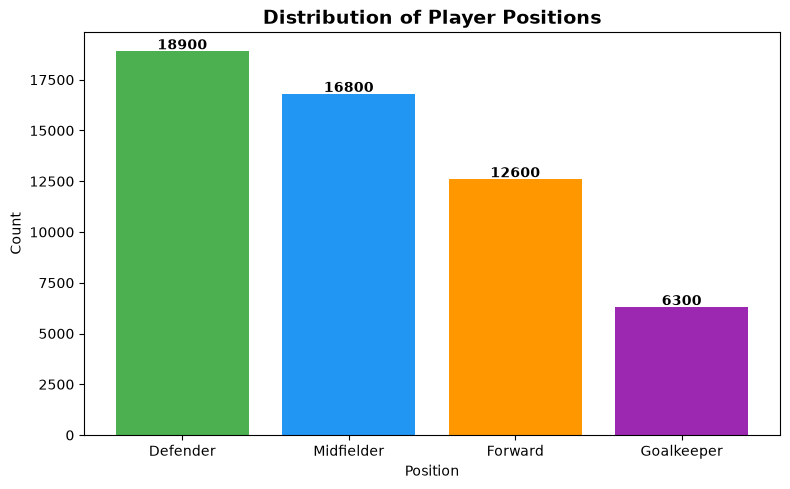


Position distribution (percentage):
position
Defender      34.62 %
Midfielder    30.77 %
Forward       23.08 %
Goalkeeper    11.54 %
Name: count, dtype: object


In [14]:
plt.figure(figsize=(8, 5))
position_counts = df['position'].value_counts()
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
bars = plt.bar(position_counts.index, position_counts.values, color=colors)
plt.title('Distribution of Player Positions', fontsize=14, fontweight='bold')
plt.xlabel('Position')
plt.ylabel('Count')
for bar, val in zip(bars, position_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nPosition distribution (percentage):')
print((position_counts / len(df) * 100).round(2).astype(str) + ' %')

### 4.3 Distribusi Target — Gol (Regresi)

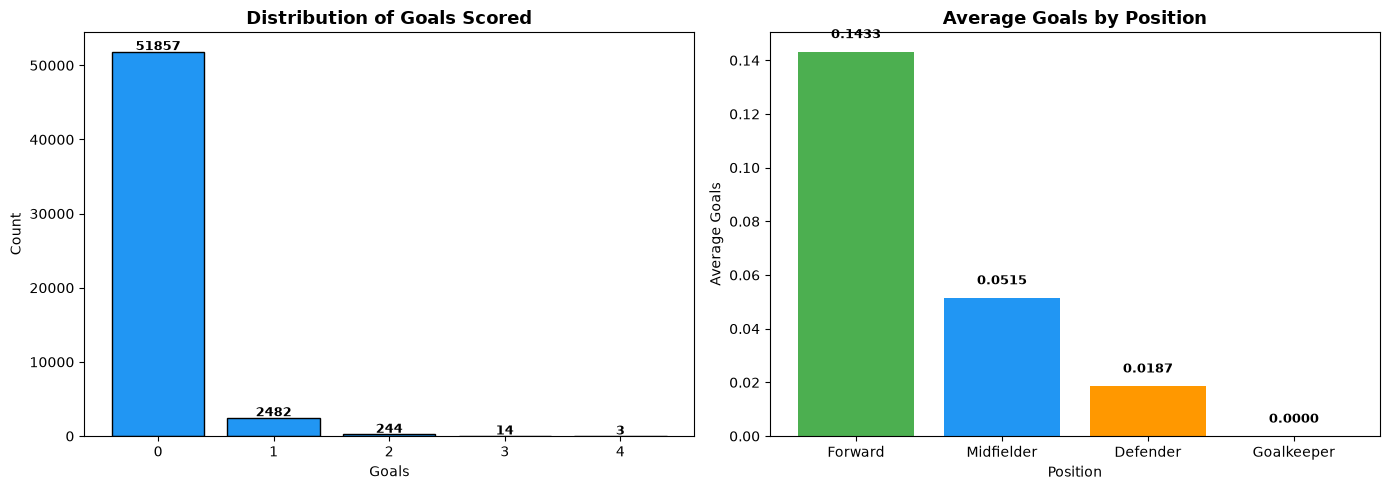

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

goals_dist = df['goals'].value_counts().sort_index()
axes[0].bar(goals_dist.index, goals_dist.values, color='#2196F3', edgecolor='black')
axes[0].set_title('Distribution of Goals Scored', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Count')
for x, y in zip(goals_dist.index, goals_dist.values):
    axes[0].text(x, y + 200, str(y), ha='center', fontsize=9, fontweight='bold')

goals_by_pos = df.groupby('position')['goals'].mean().sort_values(ascending=False)
axes[1].bar(goals_by_pos.index, goals_by_pos.values, color=colors)
axes[1].set_title('Average Goals by Position', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Average Goals')
for i, v in enumerate(goals_by_pos.values):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### 4.4 Distribusi Fitur Numerik Utama

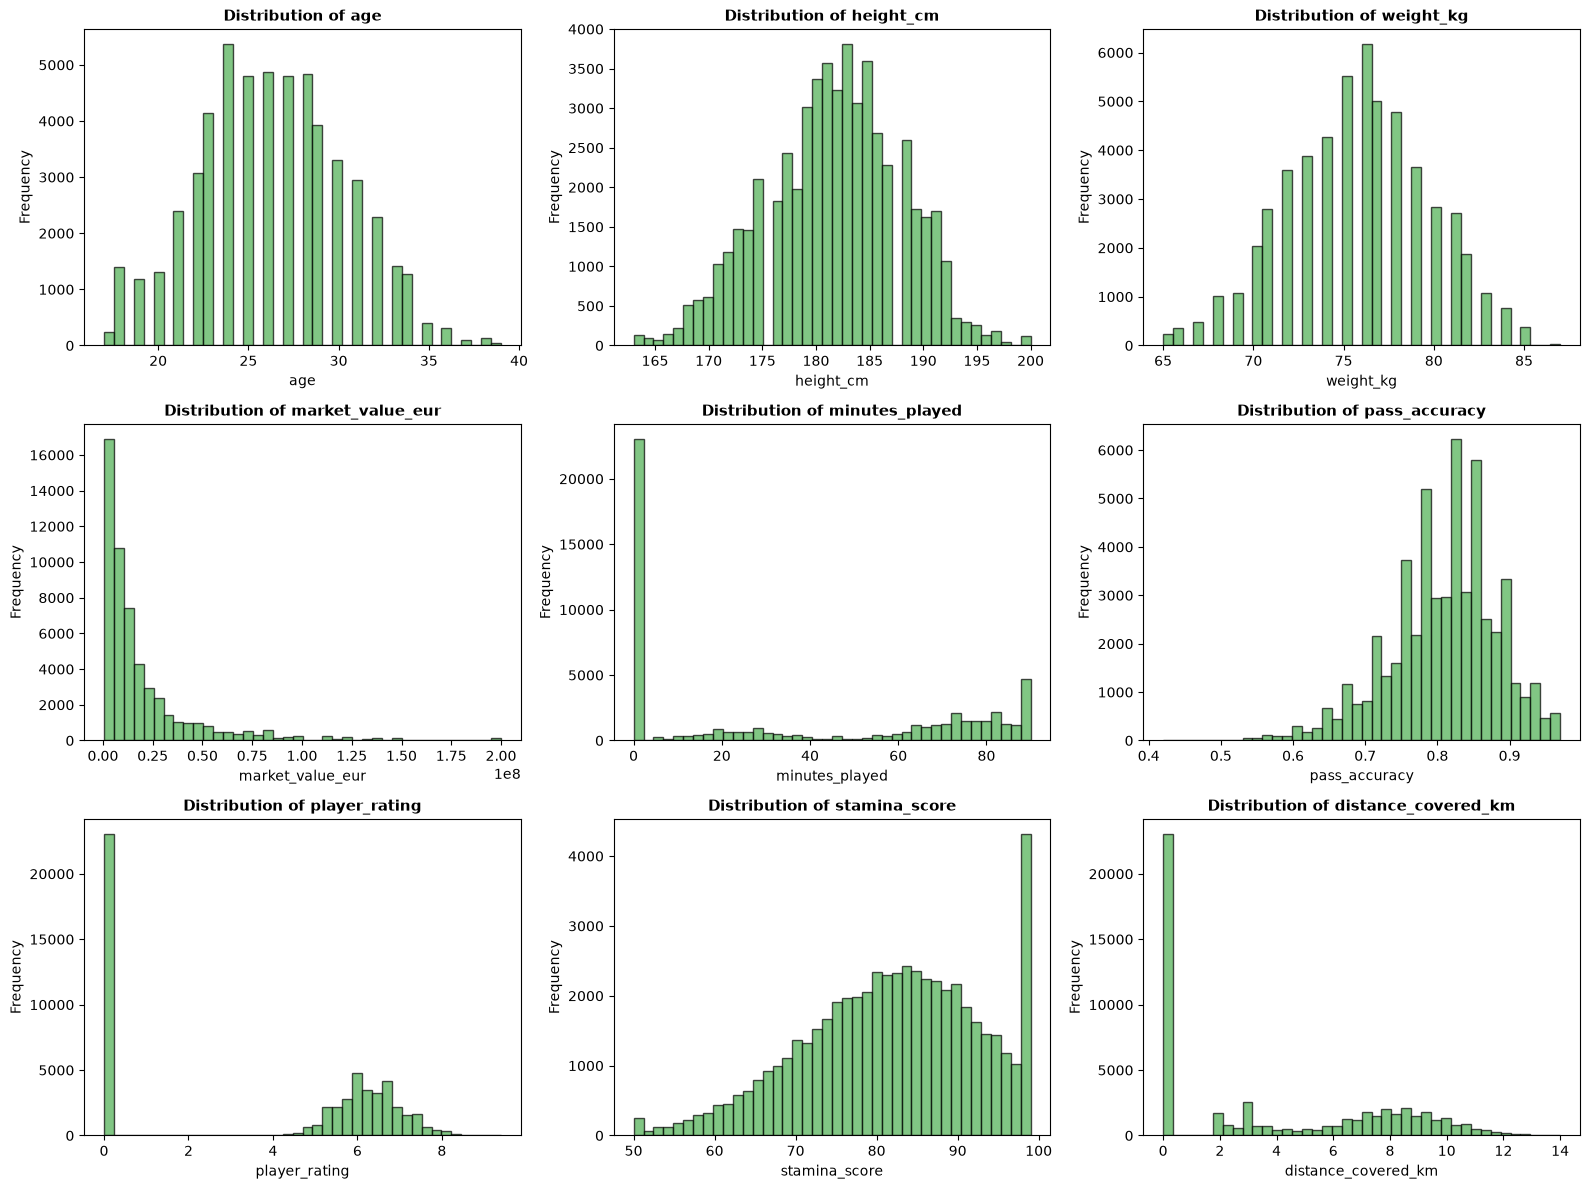

In [16]:
num_features = ['age', 'height_cm', 'weight_kg', 'market_value_eur',
                'minutes_played', 'pass_accuracy', 'player_rating',
                'stamina_score', 'distance_covered_km']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color='#4CAF50', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 4.5 Analisis Korelasi

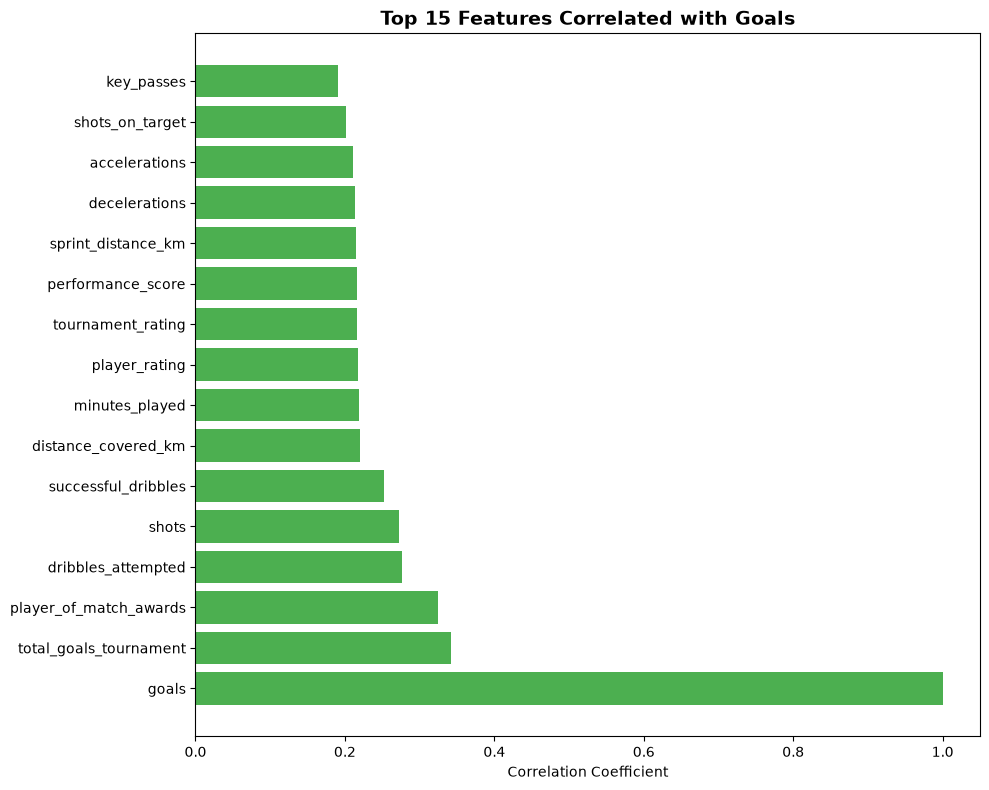

In [17]:
numeric_df = df.select_dtypes(include=[np.number])
corr_with_goals = numeric_df.corr()['goals'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
top_corrs = corr_with_goals.head(16)
colors_corr = ['#4CAF50' if v > 0 else '#F44336' for v in top_corrs.values]
plt.barh(range(len(top_corrs)), top_corrs.values, color=colors_corr)
plt.yticks(range(len(top_corrs)), top_corrs.index)
plt.title('Top 15 Features Correlated with Goals', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

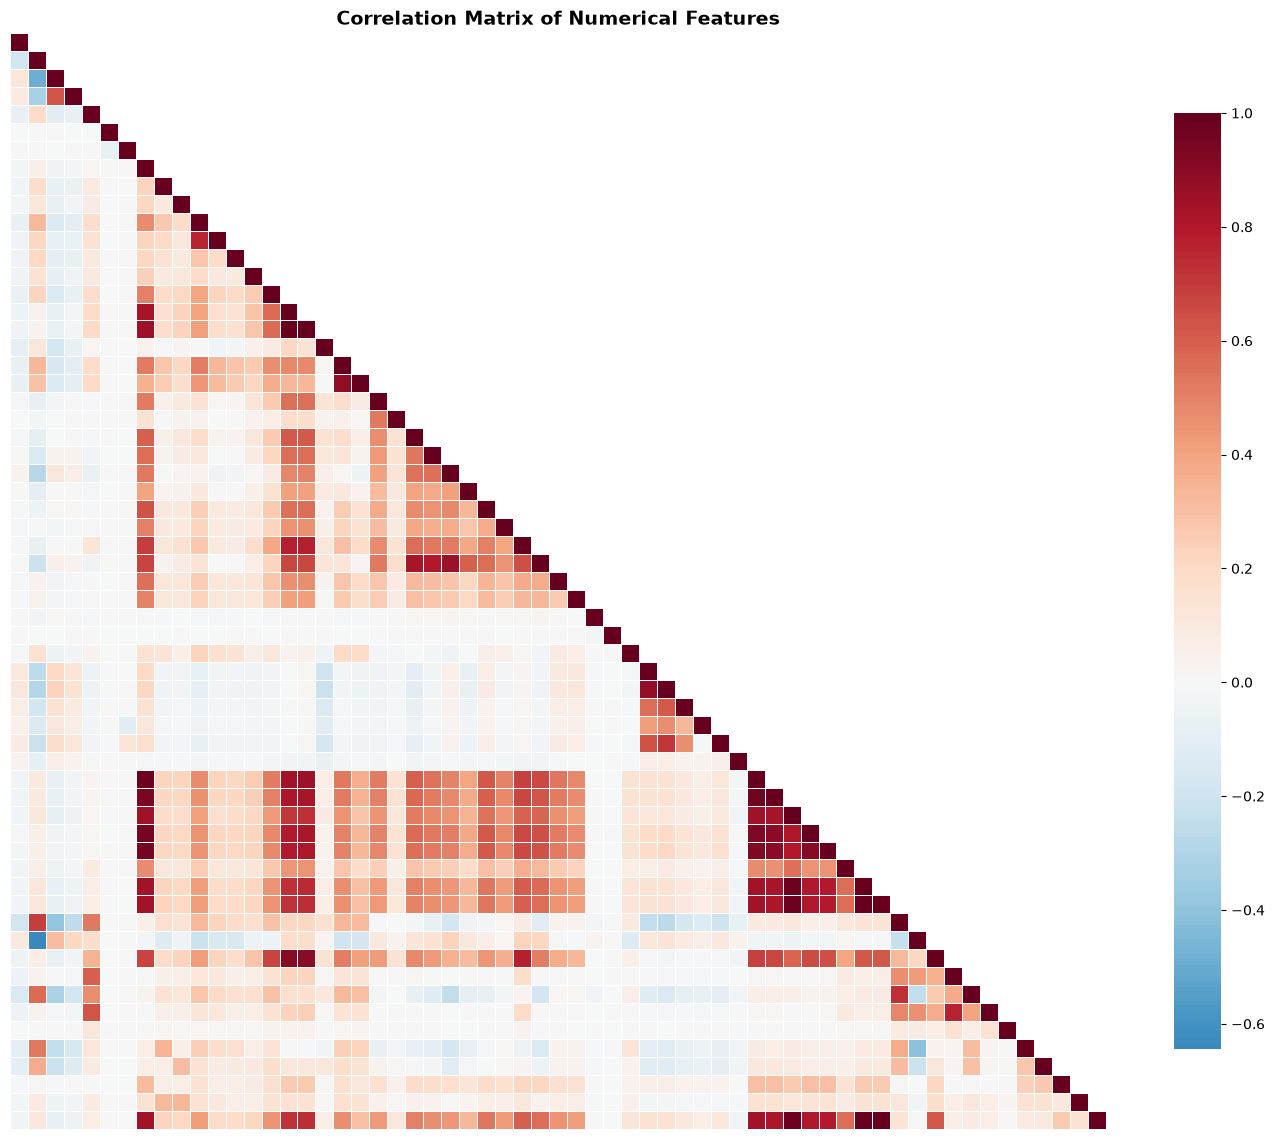

In [18]:
plt.figure(figsize=(14, 12))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            xticklabels=False, yticklabels=False)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.6 Analisis Variabel Kategorikal

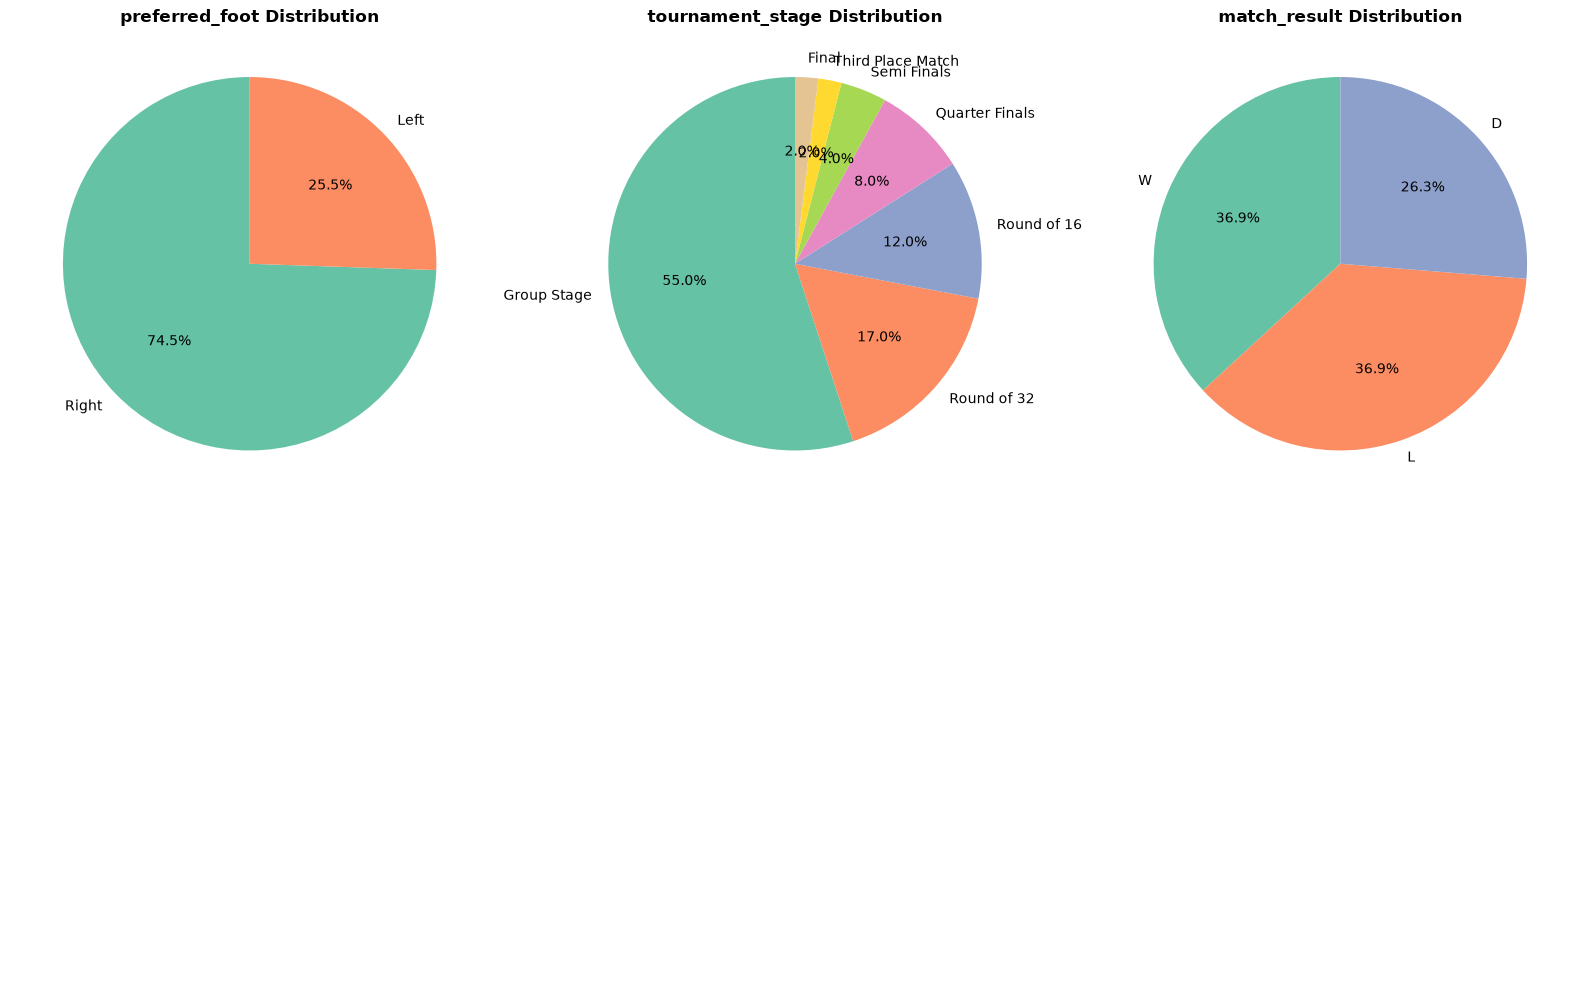

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cat_cols = ['preferred_foot', 'tournament_stage', 'match_result']
for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                startangle=90, colors=plt.cm.Set2(range(len(counts))))
    axes[i].set_title(f'{col} Distribution', fontweight='bold')

axes[3].axis('off')
axes[4].axis('off')
axes[5].axis('off')
plt.tight_layout()
plt.show()

### 4.7 Analisis Outlier

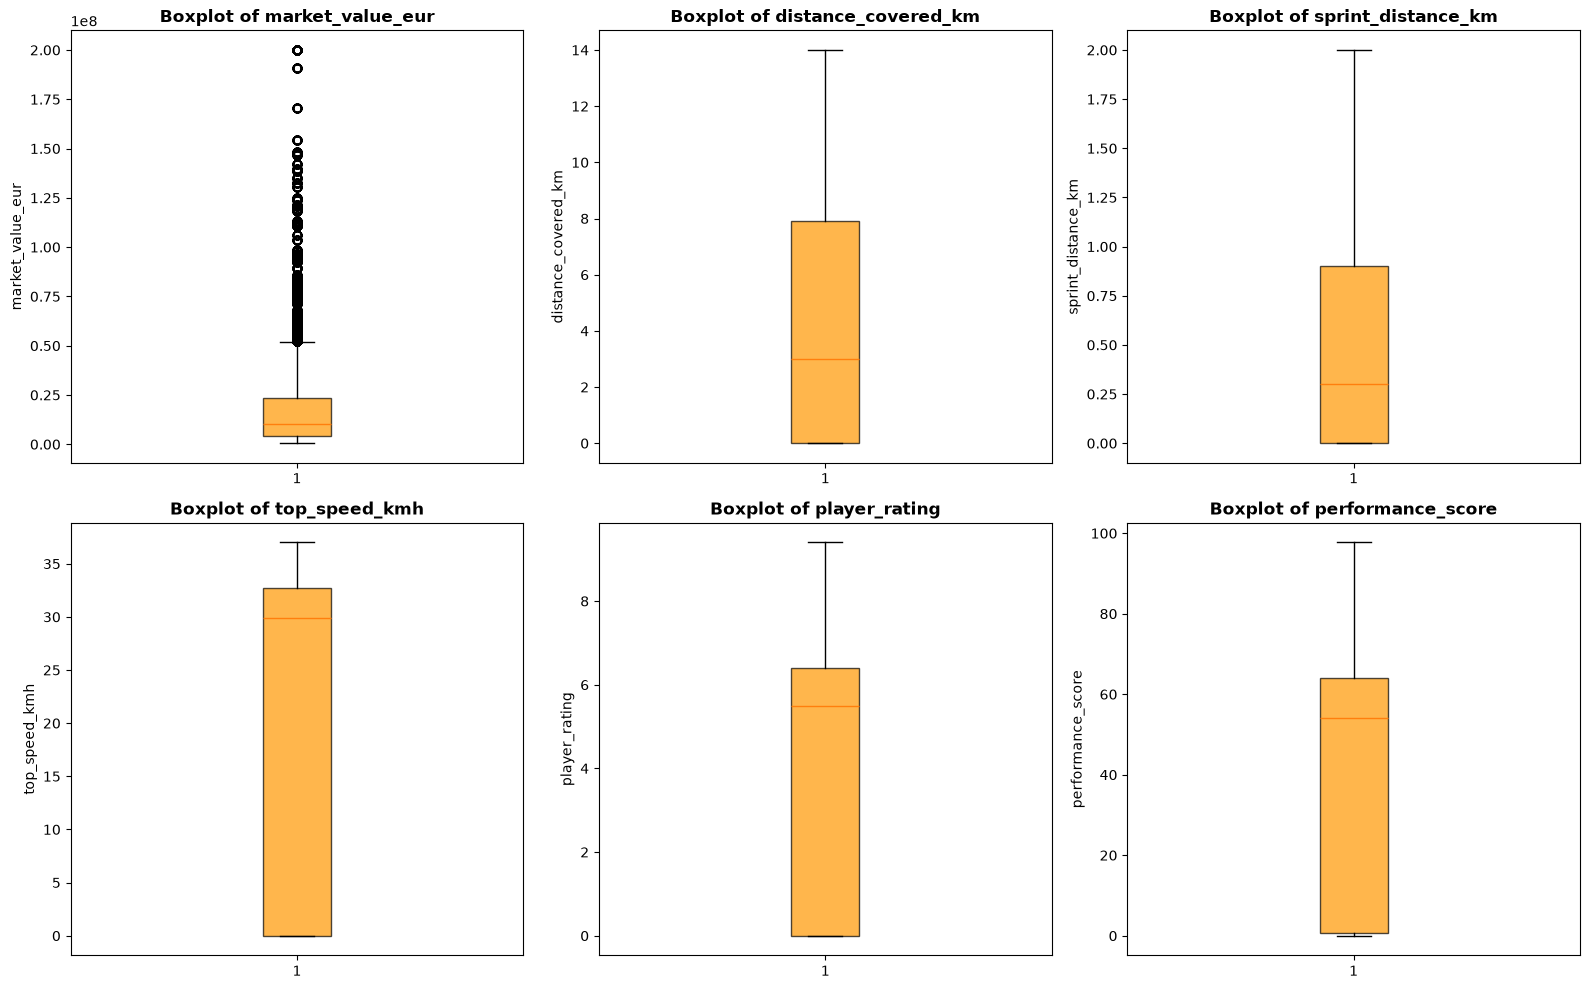

In [20]:
outlier_features = ['market_value_eur', 'distance_covered_km',
                    'sprint_distance_km', 'top_speed_kmh',
                    'player_rating', 'performance_score']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#FF9800', alpha=0.7))
    axes[i].set_title(f'Boxplot of {col}', fontweight='bold')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Data preprocessing bertujuan membersihkan dan menyiapkan data agar siap digunakan untuk model machine learning.

### 5.1 Menghapus Kolom Identitas

In [21]:
id_cols = ['player_id', 'player_name', 'match_id', 'match_date',
           'stadium', 'city', 'club_name', 'nationality', 'team', 'opponent_team']
df_processed = df.drop(columns=id_cols)
print(f'Shape after dropping ID columns: {df_processed.shape}')

Shape after dropping ID columns: (54600, 65)


### 5.2 Encoding Variabel Kategorikal

In [22]:
position_mapping = {'Defender': 0, 'Forward': 1, 'Goalkeeper': 2, 'Midfielder': 3}
df_processed['position_encoded'] = df_processed['position'].map(position_mapping)
df_processed = df_processed.drop(columns=['position'])

stage_mapping = {
    'Group Stage': 0, 'Round of 32': 1, 'Round of 16': 2,
    'Quarter Finals': 3, 'Semi Finals': 4,
    'Third Place Match': 5, 'Final': 6
}
df_processed['tournament_stage'] = df_processed['tournament_stage'].map(stage_mapping)

result_mapping = {'L': 0, 'D': 1, 'W': 2}
df_processed['match_result'] = df_processed['match_result'].map(result_mapping)

foot_mapping = {'Left': 0, 'Right': 1}
df_processed['preferred_foot'] = df_processed['preferred_foot'].map(foot_mapping)

print(f'Shape after encoding: {df_processed.shape}')
print(f'Encoded columns: position_encoded, tournament_stage, match_result, preferred_foot')

Shape after encoding: (54600, 65)
Encoded columns: position_encoded, tournament_stage, match_result, preferred_foot


### 5.3 Feature Scaling

In [23]:
target_reg = 'goals'
target_cls = 'position_encoded'

feature_cols = [c for c in df_processed.columns
                if c not in [target_reg, target_cls]]

scaler = StandardScaler()
df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

print(f'Features scaled using StandardScaler: {len(feature_cols)} features')
print(f'Final shape: {df_processed.shape}')

Features scaled using StandardScaler: 63 features
Final shape: (54600, 65)


### 5.4 Train-Test Split

In [24]:
X = df_processed.drop(columns=[target_reg, target_cls])
y_reg = df_processed[target_reg]
y_cls = df_processed[target_cls]

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X, y_reg, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_reg_train: {y_reg_train.shape}')
print(f'y_reg_test: {y_reg_test.shape}')
print(f'y_cls_train: {y_cls_train.shape}')
print(f'y_cls_test: {y_cls_test.shape}')

print(f'\nClass distribution in y_cls_train:')
print(y_cls_train.value_counts().sort_index())

X_train: (43680, 63)
X_test: (10920, 63)
y_reg_train: (43680,)
y_reg_test: (10920,)
y_cls_train: (43680,)
y_cls_test: (10920,)

Class distribution in y_cls_train:
position_encoded
0    15120
1    10080
2     5040
3    13440
Name: count, dtype: int64


### 5.5 Menyimpan Data yang Telah Diproses

In [25]:
OUTPUT_DIR = 'Membangun_model/fifa_dataset_preprocessing'
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

output_path = os.path.join(OUTPUT_DIR, 'fifa_data_clean.csv')
df_processed.to_csv(output_path, index=False)
print(f'Cleaned dataset saved to: {output_path}')
print(f'Final dataset shape: {df_processed.shape}')

Cleaned dataset saved to: Membangun_model/fifa_dataset_preprocessing/fifa_data_clean.csv
Final dataset shape: (54600, 65)


### 5.6 Ringkasan Data Preprocessing

In [26]:
print('=== Data Preprocessing Summary ===')
print(f'Original shape: {df.shape}')
print(f'Final shape: {df_processed.shape}')
print(f'\nDropped columns ({len(id_cols)}): {id_cols}')
print(f'Encoded columns: position, tournament_stage, match_result, preferred_foot')
print(f'Scaling method: StandardScaler (zero mean, unit variance)')
print(f'Number of features: {X.shape[1]}')
print(f'Regression target: goals')
print(f'Classification target: position_encoded ({len(position_mapping)} classes)')
print(f'Train-Test split: 80/20 with stratification on position_encoded')
print(f'Train size: {X_train.shape[0]} samples')
print(f'Test size: {X_test.shape[0]} samples')

=== Data Preprocessing Summary ===
Original shape: (54600, 75)
Final shape: (54600, 65)

Dropped columns (10): ['player_id', 'player_name', 'match_id', 'match_date', 'stadium', 'city', 'club_name', 'nationality', 'team', 'opponent_team']
Encoded columns: position, tournament_stage, match_result, preferred_foot
Scaling method: StandardScaler (zero mean, unit variance)
Number of features: 63
Regression target: goals
Classification target: position_encoded (4 classes)
Train-Test split: 80/20 with stratification on position_encoded
Train size: 43680 samples
Test size: 10920 samples
